In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import subprocess as sub
import time
from scipy.optimize import differential_evolution
from scipy.optimize import Bounds
from matplotlib import colors
#plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use('default')
G = 6.6742e-8
C = 2.99792458e10
Msun = 1.9891e33

In [2]:
N_spins = 12
N_dens = 20
r_ratios = np.log10(np.linspace(9.9, 6, N_spins))
eoss = np.array(pd.read_csv('../compose/max_dens.csv', header=None))
eos_names = eoss[:,0]
min_dens = eoss[:,1]
max_dens = eoss[:,2]

In [2]:
sub.run('make quasik')

CompletedProcess(args='make quasik', returncode=0)

In [40]:
incl = 20
obl = 0.898196
sub.run('./quasik.exe -f "../compose/eosFPS" -e 1.209e15 -r ' + str(obl) + ' -i ' + str(incl) + ' -p 15', capture_output=True)

CompletedProcess(args='./quasik.exe -f "../eos/eosFPS" -e 1.209e15 -r 0.898196 -i 20 -p 15', returncode=0, stdout=b'EOS file: ../eos/eosFPS, Grid size = MDIVxSDIV = 151x301\r\n\r\ne_center = 1.209e15 g/cm^3\r\nr_ratio  = 0.898196\r\nMass     = 1.40016 MSUN\r\nM/R      = 0.180322 \r\nR_e      = 11.4695 km\r\nSpin     = 699.87 Hz\r\nj = a/M  = J/M^2 = 0.329649 \r\n\r\nQuadrupole: Laarakkers and Poisson \r\nQuadrupole = -5.35504e+43 g cm^2 \r\nqscale = -0.449511 \r\nmscale = -0.465692 \r\nLP formula: q = -0.467274 \r\nQuasiKerr dimensionless quadrupole parameter: epsilon = 0.340842 \r\n\r\nComparison of QuasiKerr Metric with numerical RNS metric\r\nOmega = 4397.412711, Omega_K = 11031.339171\r\n', stderr=b'')

In [3]:
MDIV = 150
cols = 6

mapdata = np.array(pd.read_csv('zmap.csv', header=None)).reshape([2*MDIV, MDIV, cols])
theta = np.arccos(mapdata[:,:,0])
phi = mapdata[:,:,1]
zos = mapdata[:,:,2]
zcon = mapdata[:,:,3]
zqk = mapdata[:,:,4]
zqkb = mapdata[:,:,5]

cmap = plt.cm.coolwarm
cmap.set_bad(color='w')

In [16]:
def zmap(zmap, vmin=None, vmax=None):

    z_mask = np.ma.masked_where(zmap == 0, zmap).transpose()

    if vmin==None:
        vmin = zmap.min()
    if vmax==None:
        vmax = zmap.max()

    plt.figure()
    plt.pcolormesh(phi.transpose(), theta.transpose(), z_mask, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.errorbar([np.pi/2, -np.pi/2], [np.pi/2, np.pi/2], xerr=np.pi/2, yerr=np.pi/2, c='k', lw=0.4)
    plt.gca().invert_yaxis()
    plt.ylabel(r"$\theta$")
    plt.xlabel(r"$\phi$")
    plt.colorbar(label="z")
    plt.savefig("out.png", dpi=390)

In [ ]:
#zmap(zos)
#zmap(zcon)
#zmap(zqk)
#zmap(zqkb)

In [ ]:
i_0 = np.where(zos != 0)
zerr_fill = (np.abs((zcon[i_0]-zos[i_0])/(zcon[i_0]+1)))*100
zerr = np.zeros(zos.shape)
zerr[i_0] = zerr_fill

zmap(zerr)

In [11]:
def zmap_3d(zmap, vmin=None, vmax=None):

    z_mask = np.ma.masked_where(zmap == 0, zmap)

    if vmin==None:
        vmin = zmap.min()
    if vmax==None:
        vmax = zmap.max()

    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    z_mask = norm(z_mask)

    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    fig = plt.figure(figsize=plt.figaspect(obl)*2)
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(x, y, z, rcount=2*MDIV+1, ccount=2*MDIV+1, facecolors=cmap(z_mask), shade=False)
    ax.scatter([0],[0],[1.07],c='g',s=5)
    ax.view_init(elev=90-incl, azim=0)
    ax.axis("off")
    mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    mappable.set_array(z_mask)
    fig.colorbar(mappable, shrink=0.5, ax=ax)
    ax.set_box_aspect(aspect=(1, 1, obl))
    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    plt.xlabel("x")
    plt.ylabel("y")
    plt.savefig("out2.png", dpi=390)

In [ ]:
#zmap_3d(zos)
#zmap_3d(zcon)
#zmap_3d(zqk)
zmap_3d(zqkb)

In [78]:
redshifts = np.array(pd.read_csv('redshift.csv'))

mu = redshifts[:,0]

z_0 = redshifts[:,1]
z_max = redshifts[:,2]
z_min = redshifts[:,3]

z_sch = redshifts[:,4]
z_grav = redshifts[:,5]

z_os_0 = redshifts[:,6]
z_os_max = redshifts[:,7]
z_os_min = redshifts[:,8]
gamma = redshifts[:,9]

z_0_max = redshifts[:,14]
z_0_min = redshifts[:,15]

z_schv = 1/redshifts[:,10]-1
z_ker = 1/redshifts[:,11]-1
z_quk = 1/redshifts[:,12]-1
z_quk_bad = 1/redshifts[:,13]-1

In [ ]:
fig, ax = plt.subplots()
ax.plot(mu, z_0, c='k', alpha=0.3, lw=3, label='RNS')
#ax.plot(mu, z_sch, c='m', alpha=0.7, label='Schwarzschild')
#ax.plot(mu, z_grav, c='c', alpha=0.7, label='$ RNS \ g_{tt}$')
ax.plot(mu[:-1], z_os_0[:-1], c='b', alpha=0.7, label='Oblate Schwarzschild')
#ax.plot(mu, z_schv, c='brown', alpha=0.7, label='$Sch/\gamma$')
ax.plot(mu, z_ker, c='g', alpha=0.7, label='Kerr')
ax.plot(mu, z_quk, c='r', alpha=1, lw=2.2, linestyle=':', label='Quasikerr')
#ax.plot(mu, z_quk_bad, c='orange', alpha=1, lw=1, linestyle='--', label='Incorrect Quasikerr')
plt.xlabel(r"$\cos\theta$")
plt.ylabel('z')
#ax.set_ylim(0, 0.3)
ax.legend(loc='best')
#plt.savefig('output.png', dpi=390)

In [ ]:
fig, ax = plt.subplots()
ax.plot(mu, z_0, c='k', alpha=0.7, label=r'RNS $b_z=0$')
ax.plot(mu, z_max, c='b', alpha=0.7, label=r'RNS $b_z=b_{z,max}$')
ax.plot(mu, z_min, c='r', alpha=0.7, label=r'RNS $b_z=b_{z,min}$')
ax.plot(mu, z_os_0, c='g', alpha=0.7, label=r'Obl Sch $b=0$')
#ax.plot(mu, z_os_max, c='c', alpha=0.7, label=r'Obl Sch $b=b_{max}$')
#ax.plot(mu, z_os_min, c='orange', alpha=0.7, label=r'Obl Sch $b=b_{min}$')
ax.plot(mu, z_0_max, c='m', alpha=0.7, label=r'Empirical $b=b_{max}$')
ax.plot(mu, z_0_min, c='pink', alpha=0.7, label=r'Empirical $b=b_{min}$')
#ax.plot(mu, z_quk_bad, c='orange', alpha=1, lw=1, linestyle='--', label='Incorrect Quasikerr')

plt.xlabel(r'$\cos\theta$')
plt.ylabel('z')
#ax.set_ylim(0, 0.3)
ax.legend(prop={'size':8})
plt.savefig('bextreme_const.png', dpi=390)

------------------------------------------------------------------------------------------------------------------------------------------------------

In [3]:
class Eos_Set():

    def __init__(self, eos_name):

        self.name = eos_name
        self.data = np.load("star_data_"+eos_name+'.npy')
    
    def filter_index(self, i_r):

        massrange = np.array([0.9, 2.4])*Msun
        #spinrange = 800*2*np.pi
        mrrange = np.array([0.05, 1])

        indices = np.where(
        (self.data[:, i_r, 3] > massrange[0]) & 
        (self.data[:, i_r, 3] < massrange[1]) & 
        #(self.data[:, i_r, 1] < spinrange) & 
        (self.data[:, i_r, 4] > mrrange[0]) &
        (self.data[:, i_r, 4] < mrrange[1])
        )[0]
        indices = np.unique(indices)
        indices.sort()
        return indices.astype(int)
        
    def MR(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 4]

    def SPN(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 5]

    def z_rns(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 6]

    def quad(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 7]

In [4]:
Eos_array = np.empty(eos_names.size, dtype=object)

for j in range(eos_names.size):

    Eos_array[j] = Eos_Set(eos_names[j])

Nreal = np.where(eos_names == 'Pol0')[0][0]
Eos_real = np.empty(Nreal, dtype=object)

for j in range(Nreal):

    Eos_real[j] = Eos_Set(eos_names[j])

Eos_poly = np.empty(10, dtype=object)

for j in range(10):

    Eos_poly[j] = Eos_Set(eos_names[j+Nreal])

In [5]:
def old_formula(M_R, spins, params=[0.52, 1.15]):

    return 1/np.sqrt(1-2*M_R)*(1+spins**2*(params[1]*M_R**2+params[0]*M_R))-1

In [5]:
def create_fit_func(shapes):

    def general_fit(M_R, spins, params):

        # m is for MR
        # n is for Omega

        params = np.array(params).reshape(shapes)
        n = shapes[0]
        m = shapes[1]

        fit = np.ones(M_R.shape)
        for i in range(n):
            for j in range(m):
                #print(str(params[i,j])+" M/R^"+str(j+1)+" omega^"+str(2*(i+1)))
                fit += params[i,j]*M_R**(j+1)*spins**(2*(i+1))

        fit *= 1/np.sqrt(1-2*M_R)
        
        return fit-1

    return general_fit

In [ ]:
def fit_LSQ(Eos_array, shapes):

    n = shapes[0]
    m = shapes[1]

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            z_norm_p = (eos.z_rns(i_r)+1)*np.sqrt(1-2*mr)-1

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            z_norm = np.concatenate([z_norm, z_norm_p])

    X_matrix = np.ones([M_R.size, )


In [6]:
def residual_objective(params, Eos_array, fit_func):

    M_R = np.empty([0])
    spins = np.empty([0])
    z_norm = np.empty([0])

    resid=0
    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            z_norm_p = (eos.z_rns(i_r)+1)*np.sqrt(1-2*mr)-1

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            z_norm = np.concatenate([z_norm, z_norm_p])
            z_emp_p = (fit_func(mr, spn, params)+1)*np.sqrt(1-2*mr)-1
            resid += np.sum(np.abs(z_norm_p-z_emp_p))

    return resid

In [35]:
def plot_3dredshifts(Eos_array, fit_func, params):

    fig = plt.figure(figsize=plt.figaspect(0.9)*2)
    ax = fig.add_subplot(projection='3d')

    M_R = np.empty([0])
    spins = np.empty([0])
    z_norm = np.empty([0])

    resid=0
    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            z_norm_p = (eos.z_rns(i_r)+1)*np.sqrt(1-2*mr)-1

            ax.scatter(mr, spn**2, z_norm_p, alpha=0.3, s=5)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            z_norm = np.concatenate([z_norm, z_norm_p])

    M_R_mesh, spins_mesh = np.meshgrid(np.sort(M_R), np.sort(spins))
    z_emp = (fit_func(M_R_mesh, spins_mesh, params)+1)*np.sqrt(1-2*M_R_mesh)-1

    ax.plot_surface(M_R_mesh, spins_mesh**2, z_emp, color='green', alpha=0.2)
    ax.view_init(elev=15, azim=-110)
    ax.set_box_aspect(aspect=(1, 1, 1))
    font=11
    ax.tick_params(labelsize=font, pad=1)
    ax.tick_params(axis='z', labelsize=font, pad=4)
    ax.set_xlabel("M/R", labelpad=2)
    ax.set_ylabel("$\overline{\Omega}^{\ 2}$", labelpad=2)
    ax.set_zlabel("$z_{b=0}/z_S$", labelpad=8)

    #plt.savefig("3d_z.png", dpi=390)

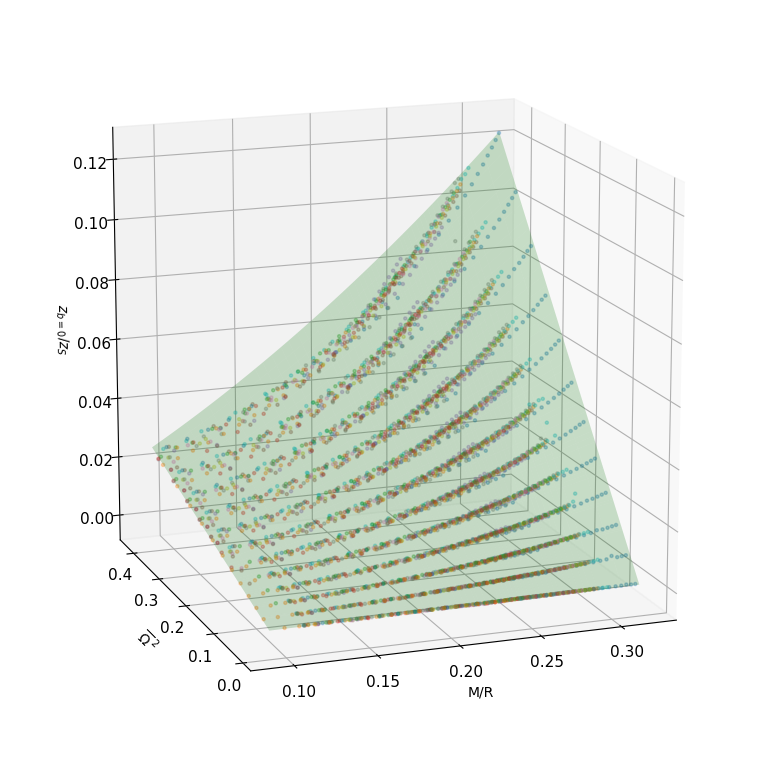

In [38]:
plot_3dredshifts(Eos_real, old_formula, [0.544, 1.13])

In [3]:
def create_dataset(i):
    
    eos = eos_names[i]
    e_min = min_dens[i]
    e_max = max_dens[i]
    ratios = r_ratios
    densities = np.linspace(e_min, e_max, N_dens)

    star_data = np.zeros([N_dens, N_spins, 11])
    i_r=0
    t_0 = time.time()
    for r in ratios:
        i_e = 0
        for e in densities:
            string = 'quasik.exe -f "../compose/eos' + eos + '" -e ' + "{:e}".format(e).replace('+', '') + ' -r ' + str(r)
            sub.run(string)
            output = np.loadtxt('star.csv', delimiter=',')
            star_data[i_e,i_r,:] = output
            print(eos+'  %i, %i ' % (i_r+1, i_e+1), end='\r')
            i_e += 1
        i_r += 1
    np.save('star_data_'+eos, star_data)
    t_f = time.time()
    t_min = round((t_f-t_0)/60, 2)
    print(eos+' done in '+str(t_min)+' minutes')
    return

In [ ]:
for i in range(eos_names.size):
    try:
        create_dataset(i)
    except ValueError:
        print(str(eos_names[i])+' failed due to ValueError')
    except TypeError:
        print(str(eos_names[i])+' failed due to TypeError')
    except Exception:
        print(str(eos_names[i])+' failed due to Exception')

APR done in 19.0 minutes
BBB done in 15.0 minutes
BLC done in 11.27 minutes
CMF1 done in 12.0 minutes
CMF1H done in 12.64 minutes
CMF2 done in 12.05 minutes
D1MStar done in 12.29 minutes


DDHdY4 done in 14.12 minutes
DDMEX done in 10.53 minutes
GDFMI done in 11.6 minutes
GDFMII done in 10.36 minutes
GM1 done in 13.22 minutes
KDE0v done in 14.38 minutes
M3 done in 12.25 minutes


NL3 done in 9.62 minutesf "../compose/eosNL3" -e 7.500000e14 -r 0.7781512503836436


PCSB2 done in 10.19 minutes
PKDD done in 10.66 minutes
QHC21A done in 12.37 minutes
QMCRMF3 done in 13.68 minutes
Rs done in 15.52 minutes
SK255 done in 14.58 minutes
Ska done in 12.88 minutes
TW done in 13.79 minutes
Pol0 done in 11.94 minutes
Pol1 done in 11.21 minutes
Pol2 done in 11.97 minutes
Pol3 done in 13.86 minutes
Pol4 done in 12.93 minutes
Pol5 done in 12.58 minutes
Pol6 done in 11.95 minutes
Pol7 done in 13.07 minutes
Pol8 done in 10.96 minutes
Pol9 done in 12.92 minutes
